num_records: 510
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
            q_len      hit@10  gold_n  pred_n
count  510.000000  510.000000   510.0   510.0
mean    20.372549    0.527451     1.0     5.0
std      6.608504    0.499736     0.0     0.0
min      6.000000    0.000000     1.0     5.0
25%     16.000000    0.000000     1.0     5.0
50%     19.000000    1.000000     1.0     5.0
75%     24.000000    1.000000     1.0     5.0
max     54.000000    1.000000     1.0     5.0
    len_bin    n  hit_rate
0    (0, 8]    2  0.000000
1   (8, 16]  156  0.461538
2  (16, 24]  237  0.514768
3  (24, 32]   93  0.623656
4  (32, 48]   18  0.777778
5  (48, 64]    4  0.750000


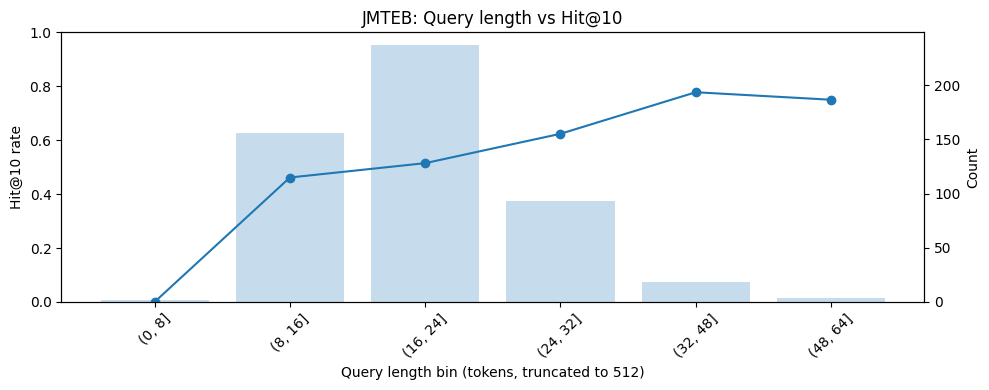

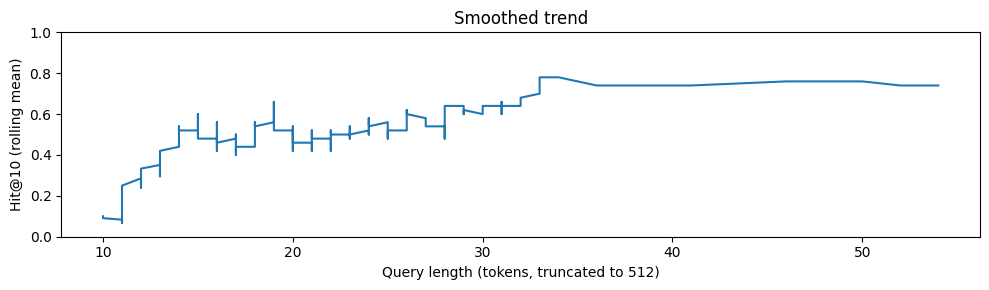

In [6]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_free/ruri_mask/Retrieval/predictions_nlp_journal_title_abs_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

num_records: 510
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
            q_len      hit@10  gold_n  pred_n
count  510.000000  510.000000   510.0   510.0
mean    20.372549    0.298039     1.0     5.0
std      6.608504    0.457846     0.0     0.0
min      6.000000    0.000000     1.0     5.0
25%     16.000000    0.000000     1.0     5.0
50%     19.000000    0.000000     1.0     5.0
75%     24.000000    1.000000     1.0     5.0
max     54.000000    1.000000     1.0     5.0
    len_bin    n  hit_rate
0    (0, 8]    2  0.000000
1   (8, 16]  156  0.217949
2  (16, 24]  237  0.286920
3  (24, 32]   93  0.387097
4  (32, 48]   18  0.666667
5  (48, 64]    4  0.500000


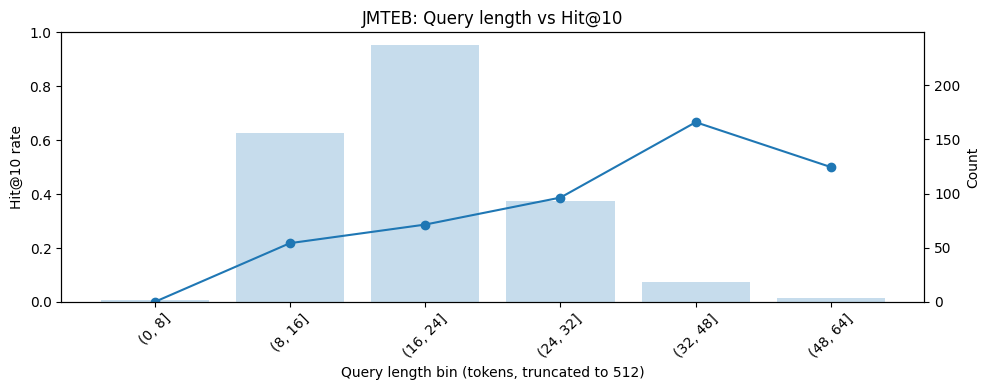

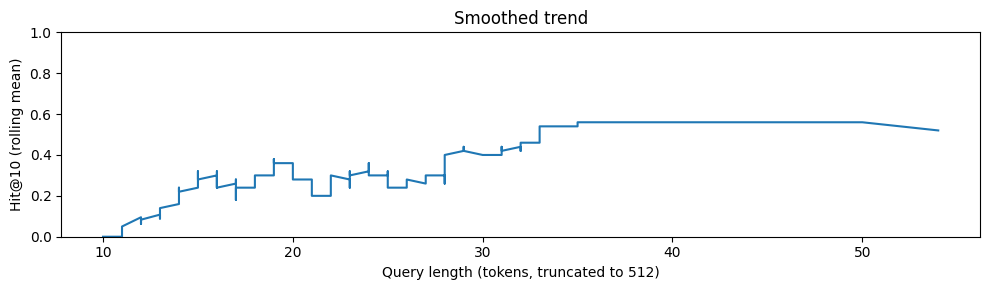

In [7]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_title_abs_Noned.jsonl"
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

/root/AIMET_ENV/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


num_records: 510
sample_keys: ['query', 'relevant_docs', 'predicted_relevant_docs']
            q_len      hit@10  gold_n  pred_n
count  510.000000  510.000000   510.0   510.0
mean    20.372549    0.527451     1.0     5.0
std      6.608504    0.499736     0.0     0.0
min      6.000000    0.000000     1.0     5.0
25%     16.000000    0.000000     1.0     5.0
50%     19.000000    1.000000     1.0     5.0
75%     24.000000    1.000000     1.0     5.0
max     54.000000    1.000000     1.0     5.0
    len_bin    n  hit_rate
0    (0, 8]    2  0.000000
1   (8, 16]  156  0.461538
2  (16, 24]  237  0.514768
3  (24, 32]   93  0.623656
4  (32, 48]   18  0.777778
5  (48, 64]    4  0.750000


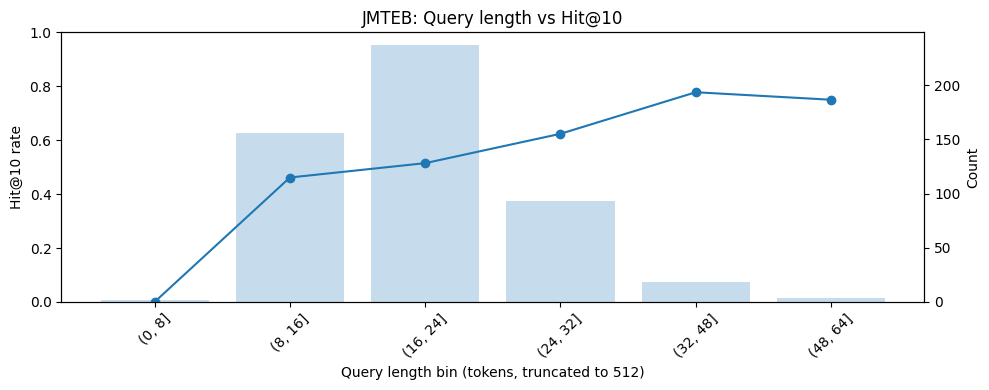

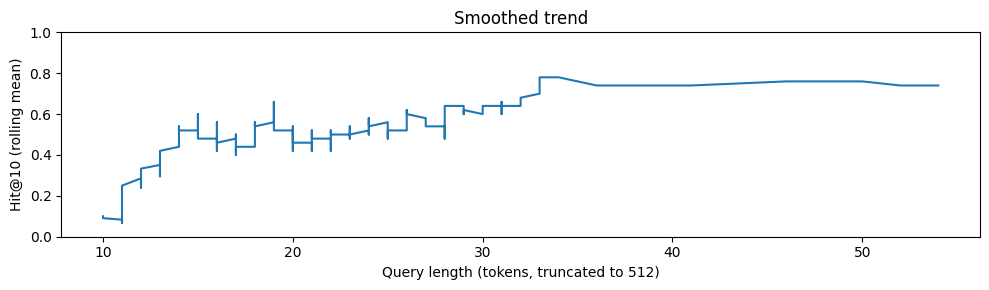

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_free/ruri_mask/Retrieval/predictions_nlp_journal_title_abs_Noned.jsonl"
#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======

#LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_quat/ruri_article_w8a16_full/Retrieval/predictions_nlp_journal_abs_intro_Noned.jsonl"
LOG_PATH = "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_soc_nosim/ruri_nosim_article/Retrieval/scores_nlp_journal_title_abs_768d.json"
TOPK = 10

MODEL_NAME = "cl-nagoya/ruri-small-v2"  # tokenizer用
MAXLEN = 512

# ビン（必要に応じて調整）
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

# ====== ログ読み込み（jsonl / json array 両対応） ======
def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)  # JSON配列
    # JSONL
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

records = load_records(LOG_PATH)
print("num_records:", len(records))
print("sample_keys:", list(records[0].keys()))

# ====== tokenizer（ローカルのみ） ======
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

# ====== クエリ長（512で切り捨て） ======
def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)  # <=512

# ====== Hit@K の計算（id一致で判定） ======
rows = []
for r in records:
    q = r["query"]

    gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}

    pred = r.get("predicted_relevant_docs", [])
    pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]

    hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0

    rows.append({
        "query": q,
        "q_len": qlen(q),     # ← ここが“常に<=512”の長さ
        "hit@10": hit,
        "gold_n": len(gold_ids),
        "pred_n": len(pred),
    })

df = pd.DataFrame(rows)
print(df[["q_len", "hit@10", "gold_n", "pred_n"]].describe())

# ====== ビン集計（q_lenは既に512で切り捨て済み） ======
df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
g = df.groupby("len_bin", observed=True).agg(
    n=("hit@10", "size"),
    hit_rate=("hit@10", "mean"),
).reset_index()

print(g)

# ====== 可視化1：命中率（折れ線）＋件数（棒） ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x = g["len_bin"].astype(str)

ax1.plot(x, g["hit_rate"], marker="o")
ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(x, g["n"], alpha=0.25)
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK}")
plt.tight_layout()
plt.show()

# ====== 可視化2：Smoothed trend（移動平均） ======
df2 = df.sort_values("q_len")
df2["hit_smooth"] = df2["hit@10"].rolling(window=50, min_periods=10).mean()

plt.figure(figsize=(10, 3))
plt.plot(df2["q_len"], df2["hit_smooth"])
plt.ylim(0, 1)
plt.xlabel("Query length (tokens, truncated to 512)")
plt.ylabel(f"Hit@{TOPK} (rolling mean)")
plt.title("Smoothed trend")
plt.tight_layout()
plt.show()

JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)

rows: 1000
columns: Index(['text'], dtype='str')
count    1000.000000
mean      411.277000
std       122.340449
min        16.000000
25%       293.000000
50%       512.000000
75%       512.000000
max       512.000000
Name: len, dtype: float64


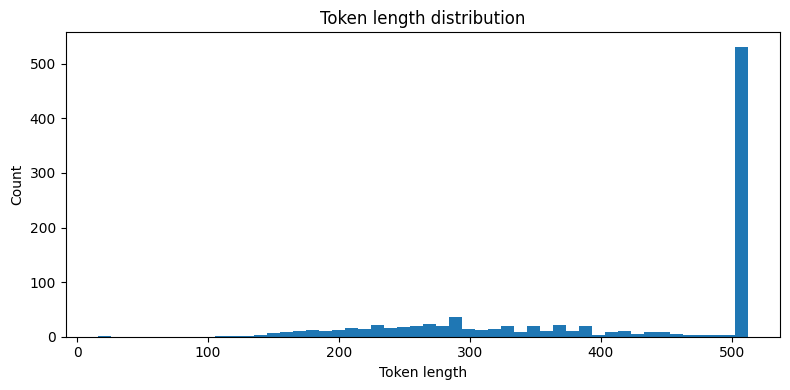

In [22]:
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ===== 設定 =====
ARROW_PATH = "/root/AIMET_ENV/tools/ruri/data/merged_1000.arrow"
TEXT_COL = "text"   # or "query"
MODEL_NAME = "cl-nagoya/ruri-small-v2"
MAXLEN = 512

# ===== Arrow読み込み =====
def load_arrow(path):
    with pa.memory_map(path, "r") as source:
        reader = ipc.RecordBatchStreamReader(source)
        table = reader.read_all()
    return table.to_pandas()

df = load_arrow(ARROW_PATH)
print("rows:", len(df))
print("columns:", df.columns)

# ===== tokenizer =====
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True
)

# ===== 長さ計算 =====
def calc_len(text):
    return len(tok(
        text,
        truncation=True,
        max_length=MAXLEN
    )["input_ids"])

df["len"] = df[TEXT_COL].astype(str).apply(calc_len)

print(df["len"].describe())

# ===== ヒストグラム =====
plt.figure(figsize=(8,4))
plt.hist(df["len"], bins=50)
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("Token length distribution")
plt.tight_layout()
plt.show()

In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ====== 設定 ======
LOG_PATHS = [
    "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/jmteb_pc/dim_768/Retrieval/predictions_jagovfaqs_22k_Noned.jsonl",
    "/root/AIMET_ENV/tools/ruri/convert/script/jmteb_result/0521/ruri_w8a16_mix_-6/Retrieval/predictions_jagovfaqs_22k_Noned.jsonl",
]
CURVE_LABELS = [
    "Experiment1",
    "Experiment2",  # 必要に応じて適切なラベルに変更
]
TOPK = 10
MODEL_NAME = "cl-nagoya/ruri-small-v2"
MAXLEN = 512
BINS = [0, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]

def load_records(path: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8").lstrip()
    if text.startswith("["):
        return json.loads(text)
    recs = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            recs.append(json.loads(line))
    return recs

# tokenizerは1度だけ準備（2ファイル共通でOK）
tok = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
    trust_remote_code=True,
    use_fast=True
)

def qlen(q: str) -> int:
    ids = tok(q, add_special_tokens=True, truncation=True, max_length=MAXLEN)["input_ids"]
    return len(ids)

def make_df(records):
    rows = []
    for r in records:
        q = r["query"]
        gold_ids = {d["id"] for d in r.get("relevant_docs", []) if "id" in d}
        pred = r.get("predicted_relevant_docs", [])
        pred_ids_topk = [d.get("id") for d in pred[:TOPK] if d.get("id") is not None]
        hit = 1 if any(pid in gold_ids for pid in pred_ids_topk) else 0
        rows.append({
            "query": q,
            "q_len": qlen(q),
            "hit@10": hit,
            "gold_n": len(gold_ids),
            "pred_n": len(pred),
        })
    return pd.DataFrame(rows)

dfs = []
gs = []
for path in LOG_PATHS:
    records = load_records(path)
    df = make_df(records)
    df["len_bin"] = pd.cut(df["q_len"], bins=BINS, right=True)
    g = df.groupby("len_bin", observed=True).agg(
        n=("hit@10", "size"),
        hit_rate=("hit@10", "mean"),
    ).reset_index()
    dfs.append(df)
    gs.append(g)

# ====== 可視化：2曲線で比較 ======
fig, ax1 = plt.subplots(figsize=(10, 4))
x_tick_labels = gs[0]["len_bin"].astype(str)
for idx, (g, label) in enumerate(zip(gs, CURVE_LABELS)):
    ax1.plot(
        x_tick_labels,
        g["hit_rate"],
        marker="o",
        label=label,
    )

ax1.set_ylabel(f"Hit@{TOPK} rate")
ax1.set_ylim(0, 1)
ax1.set_xlabel("Query length bin (tokens, truncated to 512)")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()

# 補助として 件数バー (1つ目のdfのみ)
ax2 = ax1.twinx()
ax2.bar(x_tick_labels, gs[0]["n"], alpha=0.15, color='gray', label="Count (Curve1)")
ax2.set_ylabel("Count")

plt.title(f"JMTEB: Query length vs Hit@{TOPK} (comparison)")
plt.tight_layout()
plt.show()